# Group-structure (GS) distance and multidimensional projection

This notebook walks through stages **1–5** of the individual-comparison workflow:

1. **Individual structure estimation** — one MDM per subject
2–3. **Pairwise dissimilarity matrix** — log-Bayes-factor separation (Paper #1)
4. **Multidimensional projection** — MDS / non-metric MDS embedding
5. **Visualization + proximity analysis** — scatter, dendrogram, neighbours

Implementation: `mdmp.group_analysis.distance` and `mdmp.plotting.projection`.

In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from mdmp import (
    compute_mdm_distance,
    fit_individual_structures,
    nearest_neighbours,
    plot_group_embedding,
    project_distance,
    suggest_clusters,
)

d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic two-group cohort

Group A and B differ in causal wiring (5 subjects each, 10 total); within-group distances should be smaller than across-group distances.

In [2]:
rng = np.random.default_rng(7)
n_time, n_nodes = 120, 4


def gen(kind: str) -> np.ndarray:
    e = rng.normal(0, 1, size=(n_time, n_nodes))
    x = np.zeros((n_time, n_nodes))
    x[:, 0] = e[:, 0]
    if kind == "A":
        x[:, 1] = 0.8 * x[:, 0] + 0.4 * e[:, 1]
        x[:, 2] = 0.8 * x[:, 1] + 0.4 * e[:, 2]
        x[:, 3] = e[:, 3]
    else:
        x[:, 3] = 0.8 * x[:, 0] + 0.4 * e[:, 3]
        x[:, 1] = e[:, 1]
        x[:, 2] = 0.8 * x[:, 1] + 0.4 * e[:, 2]
    return x


n_per_group = 5
subjects = [gen("A") for _ in range(n_per_group)] + [gen("B") for _ in range(n_per_group)]
subject_ids = [f"S{i:02d}" for i in range(len(subjects))]
node_names = [f"ROI{i}" for i in range(n_nodes)]

In [6]:
print(f'subjects: {len(subjects)}')
print(f'subjects shape: {subjects[0].shape}')
print(f'subject_ids: {subject_ids}')
print(f'node_names: {node_names}')

subjects: 4
subjects shape: (120, 4)
subject_ids: ['S00', 'S01', 'S02', 'S03']
node_names: ['ROI0', 'ROI1', 'ROI2', 'ROI3']


## Stage 1 — fit individual structures

In [3]:
individuals = fit_individual_structures(
    subjects,
    method="hc",
    node_names=node_names,
    subject_ids=subject_ids,
    verbose=False,
)
print(f"Fitted {len(individuals)} MDM models; example adjacency shape:", individuals[0].adj_mat.shape)

  0%|          | 3/1000000 [00:03<314:56:59,  1.13s/it]


Fitted 4 MDM models; example adjacency shape: (4, 4)


## Stages 2–3 — pairwise distance matrix

In [4]:
dist = compute_mdm_distance(
    individuals,
    metric="lpl_separation",
    subject_ids=subject_ids,
    verbose=False,
)
print("Distance matrix (rounded):")
print(np.round(dist.matrix, 2))
print("\nSimilarity view (diagonal = 1):")
print(np.round(dist.to_similarity(), 2))
display(dist.to_frame())

  0%|          | 2/1000000 [00:04<605:15:27,  2.18s/it] 


Distance matrix (rounded):
[[0.   1.16 3.02 3.33]
 [1.16 0.   1.85 2.69]
 [3.02 1.85 0.   0.76]
 [3.33 2.69 0.76 0.  ]]

Similarity view (diagonal = 1):
[[1.   0.6  0.26 0.23]
 [0.6  1.   0.44 0.31]
 [0.26 0.44 1.   0.72]
 [0.23 0.31 0.72 1.  ]]


,S00,S01,S02,S03
S00,0.000000,1.158364,3.016514,3.334451
S01,1.158364,0.000000,1.846062,2.687653
S02,3.016514,1.846062,0.000000,0.757140
S03,3.334451,2.687653,0.757140,0.000000


## Stage 4 — multidimensional projection

In [5]:
coords = project_distance(dist, technique="nmds", random_state=0)
print("Embedding shape:", coords.shape)

Embedding shape: (4, 2)


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


## Stage 5 — visualization and proximity analysis

d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\sklearn\manifold\_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


Suggested clusters: [2, 2, 1, 1]
Nearest neighbours of S00: [('S01', 1.1583641327121086), ('S02', 3.01651361054428)]


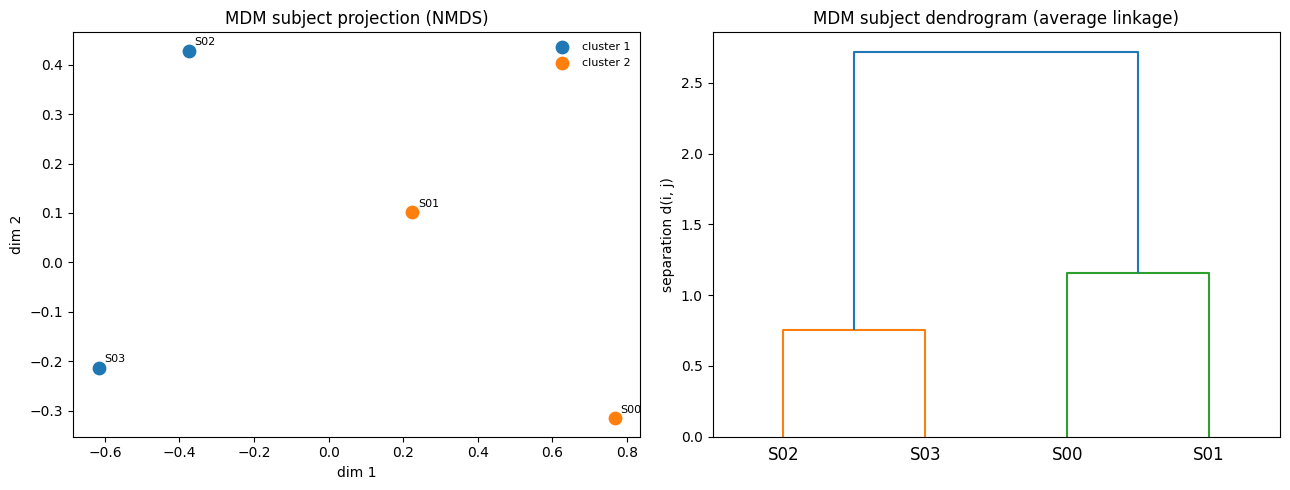

In [6]:
labels = suggest_clusters(dist)
print("Suggested clusters:", labels.tolist())
print("Nearest neighbours of S00:", nearest_neighbours(dist, "S00", k=2))

fig = plot_group_embedding(dist, technique="nmds", n_clusters=2)
plt.show()